We are trying to assess how errors in calibrator measurmements propagate to the antenna temperature. We are using Equation 1 of Monsalve+17 to determine the antenna temperature through Dicke switching:

$$T_{\rm ant}^* = \frac{P_{\rm ant} - P_{\rm load}}{P_{\rm noise} - P_{\rm load}}T_{\rm noise} + T_{\rm load}$$

Here, we are looking at interpolation errors. We take measurements where we are switching fast (every 1 minute) and use this as our nominal calibration solution. We then consider how switching at slower cadences introduces errors. For example, if we switch every 1hr, we only use every 60th of the calibration measurements and interpolate to the intermediate times. This interpolation error is propagated through the calibration equation. In this notebook, we are simulating measurements only.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from eigsep_cal.dicke import calc_Tant_star

%matplotlib widget

In [2]:
ENR = 31  # excessive noise ratio (dB)
NSIMS = 1000  # monte carlo sim number
times = np.linspace(0, 1, num=24 * 3600)  # 1 day, dt = 1 second
T_ENR = 290 * 10 ** (ENR / 10)  # noise source excess temperature (K)
T_ANT = 200  # constant antenna temperature (K)
NOM_CADENCE = 1  # nominal switching cadence (minutes)
CADENCES = [5, 15, 30, 60]  # test switching cadences (minutes)

# radiometer noise: sigma = T_sys / sqrt(bandwidth * tau)
BANDWIDTH = 100e6  # Hz
TAU = 1  # s, integration time per switch position
NOISE_STD = (
    300 / np.sqrt(BANDWIDTH * TAU),  # T_load noise (~0.03 K)
    (T_ENR + 300) / np.sqrt(BANDWIDTH * TAU),  # T_ns noise (~36.5 K)
)


def gen_cal_meas(times, physical_temp, noise_std):
    """
    Generate the calibration measurements.

    Measurement cycle:
    time = 0 - load
    time = 1 - noise source
    time = 2 - antenna
    repeat

    We assume T_load is set by the physical temperature, and the noise
    source power is the load power + the ENR.

    Parameters
    ----------
    times : array-like
        In seconds.
    physical_temp : array_like
        One value per time, with some overall variation + random scatter
    noise_std : tup of float
        Standard deviation of random variations in T_load and T_noise
        (set by radiometer equation)

    Returns
    -------
    T_load
    T_ns

    """
    n = len(times)
    T_load = physical_temp + np.random.normal(0, noise_std[0], n)
    T_ns = (
        physical_temp
        + T_ENR
        + np.random.normal(0, noise_std[1], n)
    )
    return T_load, T_ns

In [3]:
nom_idx = np.arange(0, len(times), NOM_CADENCE * 60)

rms_errors = {c: np.zeros(NSIMS) for c in CADENCES}
example = {}  # store first iteration for plotting

for i in range(NSIMS):
    # physical temperature: sinusoidal diurnal + random smooth modes
    physical_temp = 300 + 10 * np.sin(2 * np.pi * times)
    for k in range(1, 6):
        phase = np.random.uniform(0, 2 * np.pi)
        amp = np.random.normal(0, 2 / k)
        physical_temp += amp * np.sin(
            2 * np.pi * k * times + phase
        )

    T_load, T_ns = gen_cal_meas(times, physical_temp, NOISE_STD)
    P_ant = T_ANT + np.random.normal(0, NOISE_STD[0], len(times))

    # nominal: 1-min cadence, interpolated to all times
    T_load_nom = np.interp(
        times, times[nom_idx], T_load[nom_idx]
    )
    T_ns_nom = np.interp(
        times, times[nom_idx], T_ns[nom_idx]
    )
    Tant_nom = calc_Tant_star(
        P_ant, T_ns_nom, T_load_nom, T_ENR, T_load_nom
    )

    for c in CADENCES:
        idx = np.arange(0, len(times), c * 60)
        T_load_interp = np.interp(
            times, times[idx], T_load[idx]
        )
        T_ns_interp = np.interp(
            times, times[idx], T_ns[idx]
        )
        Tant_interp = calc_Tant_star(
            P_ant, T_ns_interp, T_load_interp,
            T_ENR, T_load_interp,
        )
        err = Tant_interp - Tant_nom
        rms_errors[c][i] = np.sqrt(np.mean(err**2))

        if i == 0:
            example[c] = {
                "T_load_interp": T_load_interp,
                "T_ns_interp": T_ns_interp,
                "Tant_interp": Tant_interp,
            }

    if i == 0:
        example["T_load"] = T_load.copy()
        example["T_ns"] = T_ns.copy()
        example["T_load_nom"] = T_load_nom.copy()
        example["T_ns_nom"] = T_ns_nom.copy()
        example["Tant_nom"] = Tant_nom.copy()

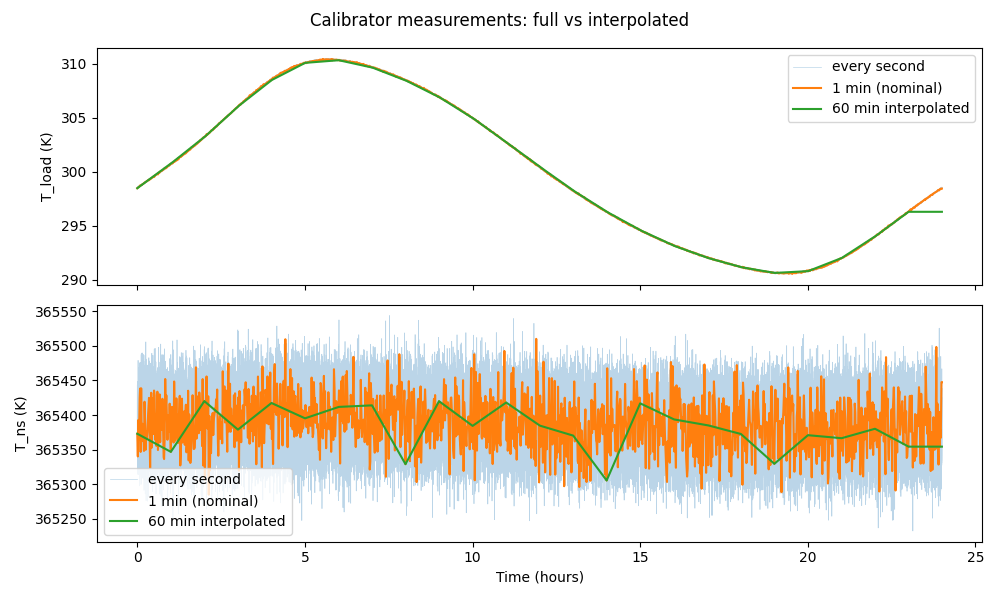

In [4]:
hours = times * 24

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax = axes[0]
ax.plot(hours, example["T_load"], alpha=0.3, lw=0.5,
        label="every second")
ax.plot(hours, example["T_load_nom"], label="1 min (nominal)")
ax.plot(hours, example[60]["T_load_interp"],
        label="60 min interpolated")
ax.set_ylabel("T_load (K)")
ax.legend()

ax = axes[1]
ax.plot(hours, example["T_ns"], alpha=0.3, lw=0.5,
        label="every second")
ax.plot(hours, example["T_ns_nom"], label="1 min (nominal)")
ax.plot(hours, example[60]["T_ns_interp"],
        label="60 min interpolated")
ax.set_ylabel("T_ns (K)")
ax.set_xlabel("Time (hours)")
ax.legend()

fig.suptitle("Calibrator measurements: full vs interpolated")
fig.tight_layout()

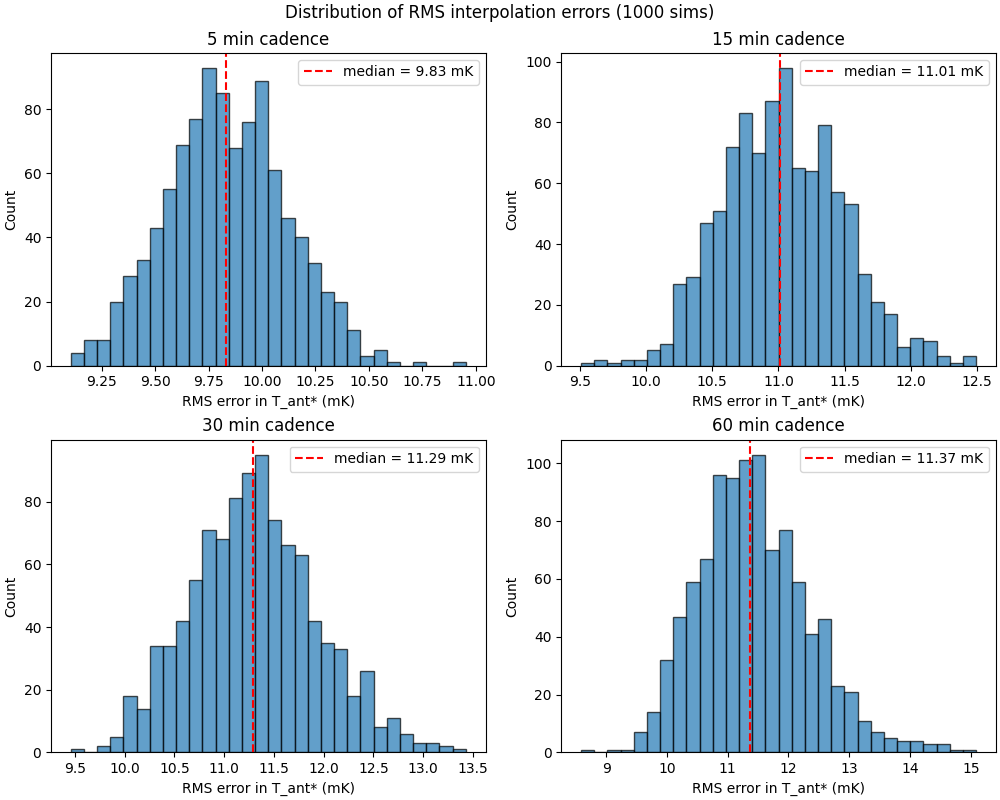

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

for ax, c in zip(axes.flat, CADENCES):
    ax.hist(rms_errors[c] * 1e3, bins=30, edgecolor="black",
            alpha=0.7)
    med = np.median(rms_errors[c]) * 1e3
    ax.axvline(med, color="red", ls="--",
               label=f"median = {med:.2f} mK")
    ax.set_xlabel("RMS error in T_ant* (mK)")
    ax.set_ylabel("Count")
    ax.set_title(f"{c} min cadence")
    ax.legend()

fig.suptitle(
    f"Distribution of RMS interpolation errors ({NSIMS} sims)"
)
plt.show()

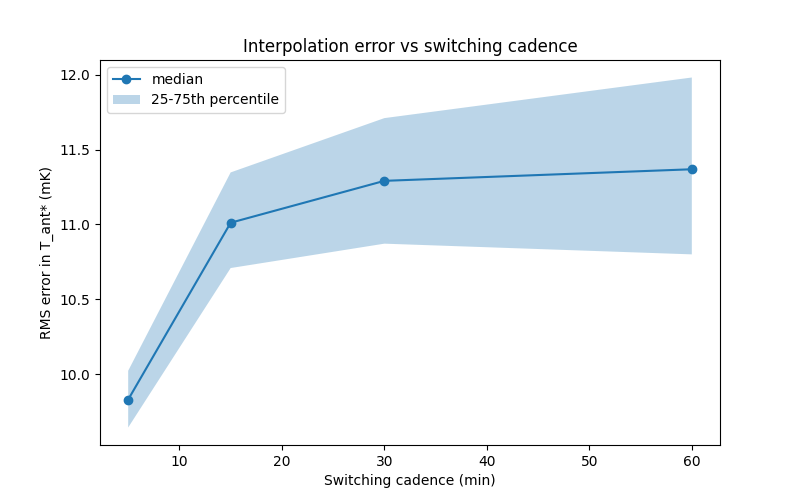

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

medians = [np.median(rms_errors[c]) * 1e3 for c in CADENCES]
q25 = [np.percentile(rms_errors[c], 25) * 1e3 for c in CADENCES]
q75 = [np.percentile(rms_errors[c], 75) * 1e3 for c in CADENCES]

ax.plot(CADENCES, medians, "o-", label="median")
ax.fill_between(CADENCES, q25, q75, alpha=0.3,
                label="25-75th percentile")
ax.set_xlabel("Switching cadence (min)")
ax.set_ylabel("RMS error in T_ant* (mK)")
ax.set_title("Interpolation error vs switching cadence")
ax.legend()
plt.show()